Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: C:\Users\MC\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip
C:\Users\MC\AppData\Local\Temp\ipykernel_23968\4065224758.py:37: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].median(), inplace=True)
C:\Users\MC\AppData\Local\Temp\ipykernel_23968\4065224758.py:38: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series throu

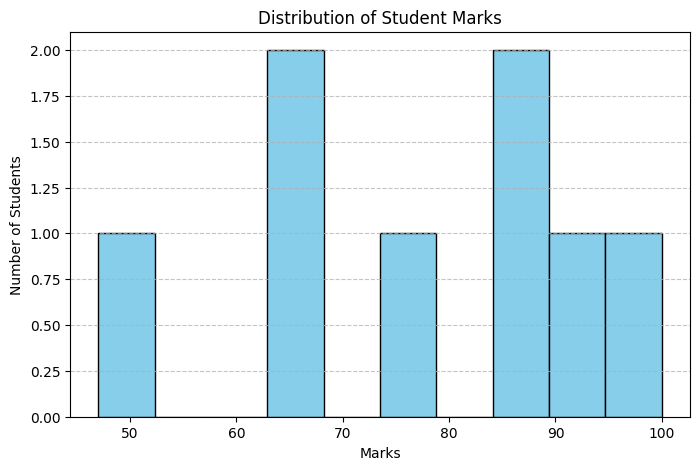

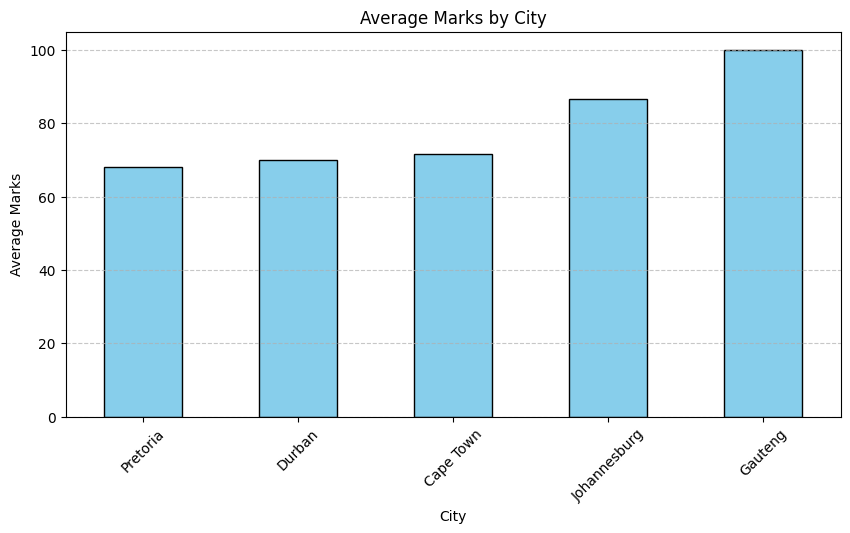

In [12]:
%pip install matplotlib
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('DataSets/DirtyData/Week_1/messy_students.csv')

#Task 1 - Familiarise yourself with the dataset
df.head()
#df.info()

df.describe(include="all")

#Task 2 - Fix whitespace, casing & duplicates

df["Name"] = df["Name"].str.strip().str.title()

df["City"] = df["City"].str.strip().str.title() 

df.head()

#Ella has one value that isnt duplicated but is a duplicate of another name
df = df.drop_duplicates(subset=["ID"], keep=False)

#Ella is then completely removed

#   Task 3 - Convert data types and handle bad values
#Checks entire column for string ages
df["Age"] = pd.to_numeric(df["Age"], errors='coerce')

#Set marks cap to 100
df.loc[df["Marks"] > 100, "Marks"] = 100


#Task 4 - Handle missing values
#Filling NaN values with median age

df["Age"].fillna(df["Age"].median(), inplace=True)
df["Enrolled"].fillna("No", inplace=True)

#Task 5 - Clean up Enrolled column

df["Enrolled"] = df["Enrolled"].str.strip().str.title()
df["Enrolled"] = df["Enrolled"].replace({"Y": "Yes", "N": "No"})
df["Enrolled"] = df["Enrolled"].map({"Yes": True, "No": False})


# Task 6 - Clean up Signup Date column - will have nulls but its fine 
df["SignupDate"] = pd.to_datetime(df["SignupDate"],errors="coerce")
# New column for month of sign up
df["SignUpMonth"] = df["SignupDate"].dt.month

#Small finishing touches

df.describe()
df.groupby("City")["Marks"].mean()


#Data Output with matlib

#Histogram of Marks

plt.figure(figsize=(8,5))
plt.hist(df["Marks"], bins=10, color='skyblue', edgecolor='black')
plt.title('Distribution of Student Marks')
plt.xlabel('Marks')
plt.ylabel('Number of Students')
plt.grid(axis='y', linestyle='--', alpha=0.75)
plt.show()

city_avg = df.groupby("City")["Marks"].mean().sort_values()

plt.figure(figsize=(10, 5))
city_avg.plot(kind="bar", color="skyblue", edgecolor="black")
plt.title("Average Marks by City")
plt.xlabel("City")
plt.ylabel("Average Marks")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


#Complete - Well done boi, you getting better day by day!!

df.to_csv('DataSets/CleanedData/Week_1/messy_students_cleaned.csv', index=False)
